In [ ]:
from scipy.io import arff
import pandas as pd

# Load the arff file
data, meta = arff.loadarff('fps-in-video-games.arff')

# Convert to a pandas DataFrame
df = pd.DataFrame(data)
# df.to_csv('fps-in-video-games.csv', index=False)

In [100]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt






In [101]:

# df = pd.read_csv('fps-in-video-games.csv')
print(df.shape)
df.head()

(425833, 45)


,CpuName,CpuNumberOfCores,CpuNumberOfThreads,CpuBaseClock,CpuCacheL1,CpuCacheL2,CpuCacheL3,CpuDieSize,CpuFrequency,CpuMultiplier,...,GpuNumberOfShadingUnits,GpuNumberOfTMUs,GpuTextureRate,GpuNumberOfTransistors,GpuVulkan,GameName,GameResolution,GameSetting,Dataset,FPS
0,b'Intel Core i7-920',4.0,8.0,133.0,256.0,1024.0,8.0,0.000263,2666.0,20.0,...,2304.0,144.0,182300.0,5700.0,b'1.2.131',b'counterStrikeGlobalOffensive',1080.0,b'low',b'userbenchmark',70.0
1,b'Intel Core i7-920',4.0,8.0,133.0,256.0,1024.0,8.0,0.000263,2666.0,20.0,...,2304.0,144.0,182300.0,5700.0,b'1.2.131',b'counterStrikeGlobalOffensive',1080.0,b'low',b'userbenchmark',230.0
2,b'Intel Core i5-4690',4.0,4.0,100.0,256.0,1024.0,6.0,0.000177,3400.0,34.0,...,2560.0,160.0,277300.0,7200.0,b'1.2.131',b'counterStrikeGlobalOffensive',1080.0,b'low',b'userbenchmark',250.0
3,b'Intel Core i5-4690',4.0,4.0,100.0,256.0,1024.0,6.0,0.000177,3400.0,34.0,...,2560.0,160.0,277300.0,7200.0,b'1.2.131',b'counterStrikeGlobalOffensive',1080.0,b'low',b'userbenchmark',300.0
4,b'Intel Core i5-4690',4.0,4.0,100.0,256.0,1024.0,6.0,0.000177,3400.0,34.0,...,896.0,56.0,61600.0,2080.0,b'1.2.131',b'counterStrikeGlobalOffensive',1080.0,b'low',b'userbenchmark',200.0


In [102]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 425833 entries, 0 to 425832
Data columns (total 45 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   CpuName                    425833 non-null  object 
 1   CpuNumberOfCores           425833 non-null  float64
 2   CpuNumberOfThreads         425833 non-null  float64
 3   CpuBaseClock               425833 non-null  float64
 4   CpuCacheL1                 425833 non-null  float64
 5   CpuCacheL2                 425833 non-null  float64
 6   CpuCacheL3                 420778 non-null  float64
 7   CpuDieSize                 223299 non-null  float64
 8   CpuFrequency               425833 non-null  float64
 9   CpuMultiplier              425833 non-null  float64
 10  CpuMultiplierUnlocked      425833 non-null  object 
 11  CpuProcessSize             425833 non-null  float64
 12  CpuTDP                     425833 non-null  float64
 13  CpuNumberOfTransistors     199794 non-nu

In [103]:
# Convert byte to string
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = df[col].astype(str).str.replace("b'", "", regex=False).str.replace("'", "", regex=False)


In [104]:
df = df.rename(columns={"GpuBus nterface": "GpuBusInterface"})

In [105]:
missing = df.isnull().sum()
missing_percent = df.isnull().mean() * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_df.sort_values("Missing %", ascending=False)

,Missing Count,Missing %
GpuNumberOfExecutionUnits,412935,96.971113
GpuNumberOfComputeUnits,357107,83.860809
CpuNumberOfTransistors,226039,53.081607
CpuDieSize,202534,47.561838
GpuBandwidth,15441,3.626069
GpuMemorySize,15441,3.626069
GpuMemoryBus,15441,3.626069
GpuNumberOfTransistors,11539,2.709748
GpuDieSize,11196,2.629200
CpuCacheL3,5055,1.187085


In [106]:
cols_to_drop = missing_percent[missing_percent > 10].index
print("Dropped columns:", cols_to_drop)
df = df.drop(columns=cols_to_drop)

Dropped columns: Index(['CpuDieSize', 'CpuNumberOfTransistors', 'GpuNumberOfComputeUnits',
       'GpuNumberOfExecutionUnits'],
      dtype='str')


In [107]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include=['object', 'string']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [108]:
# Drop duplicate
df = df.drop_duplicates()

# Drop kolom yang tidak penting (opsional)
df = df.drop(columns=["CpuName", "GpuName"], errors='ignore')

In [109]:
Q1 = df["FPS"].quantile(0.25)
Q3 = df["FPS"].quantile(0.75)
IQR = Q3 - Q1

df = df[(df["FPS"] >= Q1 - 1.5*IQR) & (df["FPS"] <= Q3 + 1.5*IQR)]

In [110]:
# check the spread for game name
print(df["GameName"].value_counts())

# Slicing the dataset to only include games with at less than 10000 samples
# df = df[df["GameName"].isin(df["GameName"].value_counts()[df["GameName"].value_counts() < 10000].index)]

GameName
counterStrikeGlobalOffensive    27021
fortnite                        22811
playerUnknownsBattlegrounds     21256
overwatch                       18789
grandTheftAuto5                 17627
leagueOfLegends                 15248
battlefield1                     9681
apexLegends                      8262
dota2                            6783
worldOfTanks                     6541
battlefield4                     5809
minecraft                        4875
callOfDutyBlackOps4              4097
rust                             3119
arkSurvivalEvolved               2915
rocketLeague                     2444
callOfDutyWW2                    1026
pathOfExile                      1026
destiny2                         1026
radicalHeights                   1026
seaOfThieves                     1026
frostpunk                        1026
totalWar3Kingdoms                1026
airMechStrike                    1026
battletech                       1026
farCry5                          1026
sta

In [111]:

le = LabelEncoder()

for col in df.select_dtypes(include=['object','string']).columns:
    df[col] = le.fit_transform(df[col])


In [112]:
X = df.drop("FPS", axis=1)
y = df["FPS"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


print("Before PCA:", X_train_scaled.shape)
print("After PCA :", X_train_pca.shape)


X_train_no_pca = X_train_scaled
X_test_no_pca = X_test_scaled

Before PCA: (153312, 38)
After PCA : (153312, 18)


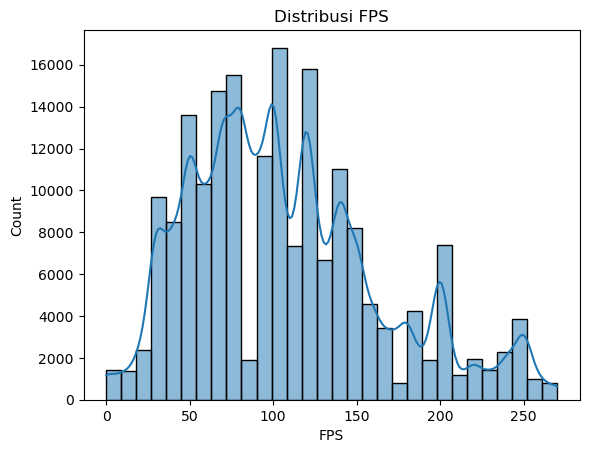

In [113]:
sns.histplot(df["FPS"], bins=30, kde=True)
plt.title("Distribusi FPS")
plt.show()

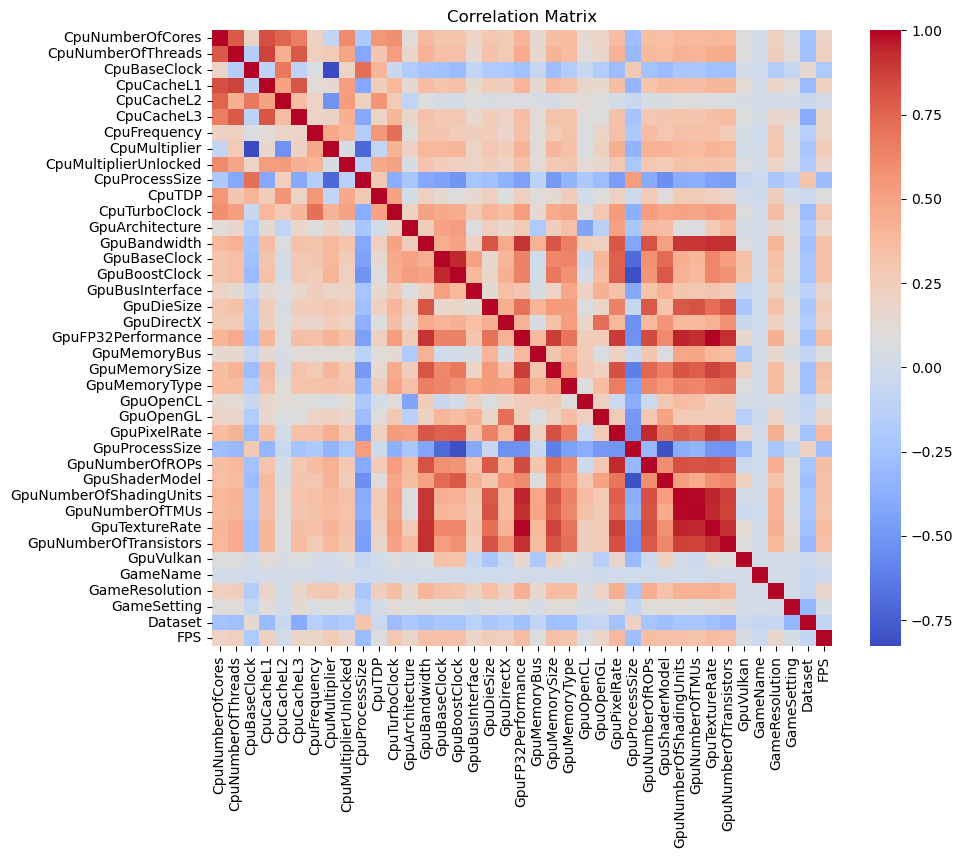

In [114]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

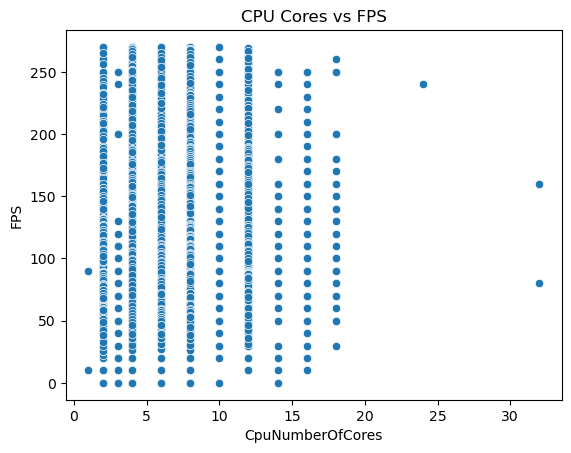

In [115]:
sns.scatterplot(x=df["CpuNumberOfCores"], y=df["FPS"])
plt.title("CPU Cores vs FPS")
plt.show()

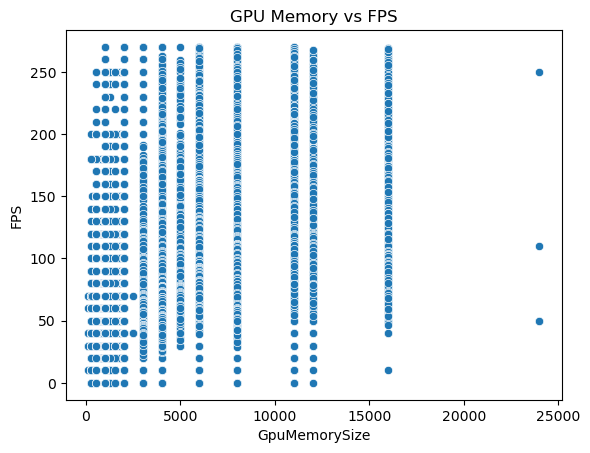

In [116]:
sns.scatterplot(x=df["GpuMemorySize"], y=df["FPS"])
plt.title("GPU Memory vs FPS")
plt.show()

<Axes: xlabel='GameResolution', ylabel='FPS'>

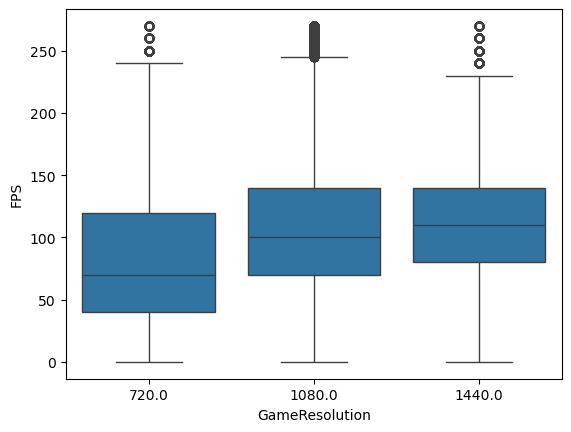

In [117]:
sns.boxplot(x=df["GameResolution"], y=df["FPS"])


In [118]:
def evaluate_model(y_true, y_pred, model_name=None):

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    if model_name is not None:
        print(f"\n{model_name}")

    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)

    return {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

In [119]:
lr_pca = LinearRegression()

lr_pca.fit(X_train_pca, y_train)

y_pred_lr_pca = lr_pca.predict(X_test_pca)

print("Linear Regression WITH PCA")
evaluate_model(y_test, y_pred_lr_pca)


lr_no_pca = LinearRegression()

lr_no_pca.fit(X_train_no_pca, y_train)

y_pred_lr_no_pca = lr_no_pca.predict(X_test_no_pca)

print("\nLinear Regression WITHOUT PCA")
evaluate_model(y_test, y_pred_lr_no_pca)

Linear Regression WITH PCA
RMSE: 51.81095071231233
MAE : 40.69180094101198
R2  : 0.18396054313125432

Linear Regression WITHOUT PCA
RMSE: 51.65346709376512
MAE : 40.55497557495813
R2  : 0.18891384092376462


{'RMSE': np.float64(51.65346709376512),
 'MAE': 40.55497557495813,
 'R2': 0.18891384092376462}

In [120]:

# =========================
# BASELINE ANN WITHOUT PCA
# =========================
inputs_no_pca = keras.Input(shape=(X_train_no_pca.shape[1],))

x = layers.Dense(64, activation='relu')(inputs_no_pca)
x = layers.Dense(32, activation='relu')(x)

outputs = layers.Dense(1)(x)

baseline_model_no_pca = keras.Model(
    inputs=inputs_no_pca,
    outputs=outputs
)

baseline_model_no_pca.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history_no_pca = baseline_model_no_pca.fit(
    X_train_no_pca,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

y_pred_baseline_no_pca = baseline_model_no_pca.predict(X_test_no_pca)

Epoch 1/20
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - loss: 3086.3848 - mae: 42.8666 - val_loss: 2698.2598 - val_mae: 40.4043
Epoch 2/20
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - loss: 2653.5349 - mae: 40.3467 - val_loss: 2660.8408 - val_mae: 40.6817
Epoch 3/20
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 2632.9014 - mae: 40.1786 - val_loss: 2636.5386 - val_mae: 40.3400
Epoch 4/20
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 2597.2866 - mae: 39.8828 - val_loss: 2603.6394 - val_mae: 39.7302
Epoch 5/20
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 2567.7090 - mae: 39.6227 - val_loss: 2590.4888 - val_mae: 40.0041
Epoch 6/20
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 2556.7390 - mae: 39.5360 - val_loss: 2571.6494 - val_mae: 39.6751
Epoch 7/20
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 2548.8792 - mae: 39.4619 - val_loss: 2570.3167 - val_mae: 39.4412
Epoch 8/20
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 2537.0469 - mae: 39.3624 - val_loss: 25

In [121]:
# =========================
# BASELINE ANN WITH PCA
# =========================
inputs_pca = keras.Input(shape=(X_train_pca.shape[1],))

x = layers.Dense(64, activation='relu')(inputs_pca)
x = layers.Dense(32, activation='relu')(x)

outputs = layers.Dense(1)(x)

baseline_model_pca = keras.Model(
    inputs=inputs_pca,
    outputs=outputs
)

baseline_model_pca.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history_pca = baseline_model_pca.fit(
    X_train_pca,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

y_pred_baseline_pca = baseline_model_pca.predict(X_test_pca)


Epoch 1/20
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 3107.1938 - mae: 42.9403 - val_loss: 2691.4065 - val_mae: 40.9889
Epoch 2/20
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 2657.9629 - mae: 40.3784 - val_loss: 2657.0576 - val_mae: 40.2010
Epoch 3/20
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 2594.1821 - mae: 39.8389 - val_loss: 2503.2632 - val_mae: 39.0386
Epoch 4/20
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 2394.6152 - mae: 38.2088 - val_loss: 2322.2605 - val_mae: 37.3838
Epoch 5/20
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 2274.0017 - mae: 37.1079 - val_loss: 2248.0190 - val_mae: 36.8085
Epoch 6/20
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 2224.4404 - mae: 36.5991 - val_loss: 2211.6113 - val_mae: 36.3885
Epoch 7/20
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 2183.8916 - mae: 36.1885 - val_loss: 2168.6292 - val_mae: 36.0524
Epoch 8/20
3833/3833 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 2149.1160 - mae: 35.8385 - val_loss: 2145.

In [122]:
print("Linear Regression WITH PCA")
evaluate_model(y_test, y_pred_lr_pca)

print("\nLinear Regression WITHOUT PCA")
evaluate_model(y_test, y_pred_lr_no_pca)

pca_results = evaluate_model(
    y_test,
    y_pred_baseline_pca,
    "Baseline ANN (PCA)"
)

non_pca_results = evaluate_model(
    y_test,
    y_pred_baseline_no_pca,
    "Baseline ANN (No PCA)"
)

Linear Regression WITH PCA
RMSE: 51.81095071231233
MAE : 40.69180094101198
R2  : 0.18396054313125432

Linear Regression WITHOUT PCA
RMSE: 51.65346709376512
MAE : 40.55497557495813
R2  : 0.18891384092376462

Baseline ANN (PCA)
RMSE: 44.577808804669665
MAE : 34.44686298352944
R2  : 0.3959046824080419

Baseline ANN (No PCA)
RMSE: 44.64203337849419
MAE : 34.07872111053861
R2  : 0.3941627523352629


In [123]:
if non_pca_results["R2"] > pca_results["R2"]:
    USE_PCA = False
    print("\nNon-PCA performs better.")
else:
    USE_PCA = True
    print("\nPCA performs better.")


PCA performs better.


In [124]:
# kf = KFold(n_splits=5, shuffle=True, random_state=42)

# lr_cv = cross_val_score(lr, X_train_pca, y_train, cv=kf, scoring='r2')

# print("LR CV R2:", lr_cv.mean())


In [127]:
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

class NoTensorBoardTuner(kt.RandomSearch):
    def _configure_tensorboard_dir(self, *args, **kwargs):
        return

if non_pca_results["R2"] > pca_results["R2"]:

    USE_PCA = False

    X_train_model = X_train_no_pca
    X_test_model = X_test_no_pca

    print("\nUsing NON-PCA dataset for tuning.")

else:

    USE_PCA = True

    X_train_model = X_train_pca
    X_test_model = X_test_pca

    print("\nUsing PCA dataset for tuning.")

def build_model(hp):

    num_units = hp.Choice(
        "num_units",
        [64, 128, 256]
    )

    dropout_rate = hp.Choice(
        "dropout_rate",
        [0.1, 0.2, 0.3]
    )

    learning_rate = hp.Choice(
        "learning_rate",
        [1e-3, 5e-4, 1e-4]
    )

    inputs = keras.Input(
        shape=(X_train_model.shape[1],)
    )

    x = layers.Dense(
        num_units,
        activation="relu"
    )(inputs)

    x = layers.Dropout(
        dropout_rate
    )(x)

    x = layers.Dense(
        num_units // 2,
        activation="relu"
    )(x)

    outputs = layers.Dense(1)(x)

    model = keras.Model(
        inputs,
        outputs
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model


early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

tuner = NoTensorBoardTuner(
    build_model,
    objective="val_loss",
    max_trials=10,
    directory="tuning",
    project_name=f"{'pca' if USE_PCA else 'non_pca'}_regression",
    overwrite=True
)

tuner.search(
    X_train_model,
    y_train,
    validation_split=0.3,
    epochs=100,
    batch_size=kt.engine.hyperparameters.HyperParameters().Choice(
        "batch_size",
        [32, 64]
    ),
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=2
)


Trial 10 Complete [00h 12m 25s]
val_loss: 1614.5335693359375

Best val_loss So Far: 1571.2921142578125
Total elapsed time: 01h 58m 08s


In [128]:
best_result = tuner.results_summary()
best_result

Results summary
Results in tuning\pca_regression
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 04 summary
Hyperparameters:
num_units: 128
dropout_rate: 0.1
learning_rate: 0.001
Score: 1571.2921142578125

Trial 08 summary
Hyperparameters:
num_units: 256
dropout_rate: 0.3
learning_rate: 0.001
Score: 1578.992431640625

Trial 09 summary
Hyperparameters:
num_units: 128
dropout_rate: 0.3
learning_rate: 0.001
Score: 1614.5335693359375

Trial 02 summary
Hyperparameters:
num_units: 64
dropout_rate: 0.2
learning_rate: 0.0005
Score: 1674.1124267578125

Trial 01 summary
Hyperparameters:
num_units: 64
dropout_rate: 0.1
learning_rate: 0.0005
Score: 1683.9820556640625

Trial 07 summary
Hyperparameters:
num_units: 256
dropout_rate: 0.2
learning_rate: 0.0001
Score: 1743.4464111328125

Trial 05 summary
Hyperparameters:
num_units: 256
dropout_rate: 0.3
learning_rate: 0.0001
Score: 1965.2017822265625

Trial 06 summary
Hyperparameters:
num_units: 128
dropout_rate: 0.2
learning_r

In [129]:
best_model = tuner.get_best_models(num_models=1)[0]
best_hp = tuner.get_best_hyperparameters(1)[0]

print("Best Model Summary")
best_model.summary()
print("\nBest Hyperparameters")
print(best_hp.values)


Best Model Summary


d:\Users\bsi80269\.conda\envs\myenv\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,753 (42.00 KB)

 Trainable params: 10,753 (42.00 KB)

 Non-trainable params: 0 (0.00 B)


Best Hyperparameters
{'num_units': 128, 'dropout_rate': 0.1, 'learning_rate': 0.001}


In [130]:

y_pred_best = best_model.predict(X_test_pca)
print("\nBest ANN Performance")
evaluate_model(y_test, y_pred_best)




1198/1198 ━━━━━━━━━━━━━━━━━━━━ 1s 880us/step

Best ANN Performance
RMSE: 39.00723329925804
MAE : 28.94780683350996
R2  : 0.537450377625224


{'RMSE': np.float64(39.00723329925804),
 'MAE': 28.94780683350996,
 'R2': 0.537450377625224}

In [133]:
# =========================
# XGBOOST REGRESSOR
# =========================

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    objective='reg:squarederror',
    random_state=42
)

xgb_model.fit(X_train_model, y_train)

y_pred_xgb = xgb_model.predict(X_test_model)

print("XGBoost Performance")
evaluate_model(y_test, y_pred_xgb)

XGBoost Performance
RMSE: 42.25715828076313
MAE : 31.946946013757564
R2  : 0.4571640377655172


{'RMSE': np.float64(42.25715828076313),
 'MAE': 31.946946013757564,
 'R2': 0.4571640377655172}

In [135]:
# hyperparameter tuning for xgboost regressor
from sklearn.model_selection import GridSearchCV
xgb_param_grid = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.03, 0.1],
    'max_depth': [4, 6, 8],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 10]
}
xgb_grid = GridSearchCV(
    estimator=XGBRegressor(objective='reg:squarederror', random_state=42),
    param_grid=xgb_param_grid,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=2,
    n_jobs=-1
)
xgb_grid.fit(X_train_model, y_train)
print("Best XGBoost Hyperparameters:", xgb_grid.best_params_)
best_xgb = xgb_grid.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_test_model)
print("\nBest XGBoost Performance")


Fitting 3 folds for each of 1458 candidates, totalling 4374 fits
Best XGBoost Hyperparameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 300, 'reg_alpha': 1, 'reg_lambda': 10, 'subsample': 1.0}

Best XGBoost Performance


In [136]:
# best xgb model performance
evaluate_model(y_test, y_pred_best_xgb) 

RMSE: 40.1004283549135
MAE : 29.95872708099467
R2  : 0.5111607617069354


{'RMSE': np.float64(40.1004283549135),
 'MAE': 29.95872708099467,
 'R2': 0.5111607617069354}

In [145]:
# ========================
compare_results = pd.DataFrame({
    "Model": [
        "Linear Regression (PCA)",
        "Linear Regression (No PCA)",
        "Baseline ANN (PCA)",
        "Baseline ANN (No PCA)",
        "Tuned ANN",
        "XGBoost Regressor",
        "Tuned XGBoost Regressor"
    ],
    "RMSE": [
        evaluate_model(y_test, y_pred_lr_pca)["RMSE"],
        evaluate_model(y_test, y_pred_lr_no_pca)["RMSE"],
        pca_results["RMSE"],
        non_pca_results["RMSE"],
        evaluate_model(y_test, y_pred_best)["RMSE"],
        evaluate_model(y_test, y_pred_xgb)["RMSE"],
        evaluate_model(y_test, y_pred_best_xgb)["RMSE"]
    ],
    "MAE": [
        evaluate_model(y_test, y_pred_lr_pca)["MAE"],
        evaluate_model(y_test, y_pred_lr_no_pca)["MAE"],
        pca_results["MAE"],
        non_pca_results["MAE"],
        evaluate_model(y_test, y_pred_best)["MAE"],
        evaluate_model(y_test, y_pred_xgb)["MAE"],
        evaluate_model(y_test, y_pred_best_xgb)["MAE"]
    ],
    "R2": [
        evaluate_model(y_test, y_pred_lr_pca)["R2"],
        evaluate_model(y_test, y_pred_lr_no_pca)["R2"],
        pca_results["R2"],
        non_pca_results["R2"],
        evaluate_model(y_test, y_pred_best)["R2"],
        evaluate_model(y_test, y_pred_xgb)["R2"],
        evaluate_model(y_test, y_pred_best_xgb)["R2"]
    ]
})
compare_results = compare_results.sort_values("R2", ascending=False)
print(compare_results)

RMSE: 51.81095071231233
MAE : 40.69180094101198
R2  : 0.18396054313125432
RMSE: 51.65346709376512
MAE : 40.55497557495813
R2  : 0.18891384092376462
RMSE: 39.00723329925804
MAE : 28.94780683350996
R2  : 0.537450377625224
RMSE: 42.25715828076313
MAE : 31.946946013757564
R2  : 0.4571640377655172
RMSE: 40.1004283549135
MAE : 29.95872708099467
R2  : 0.5111607617069354
RMSE: 51.81095071231233
MAE : 40.69180094101198
R2  : 0.18396054313125432
RMSE: 51.65346709376512
MAE : 40.55497557495813
R2  : 0.18891384092376462
RMSE: 39.00723329925804
MAE : 28.94780683350996
R2  : 0.537450377625224
RMSE: 42.25715828076313
MAE : 31.946946013757564
R2  : 0.4571640377655172
RMSE: 40.1004283549135
MAE : 29.95872708099467
R2  : 0.5111607617069354
RMSE: 51.81095071231233
MAE : 40.69180094101198
R2  : 0.18396054313125432
RMSE: 51.65346709376512
MAE : 40.55497557495813
R2  : 0.18891384092376462
RMSE: 39.00723329925804
MAE : 28.94780683350996
R2  : 0.537450377625224
RMSE: 42.25715828076313
MAE : 31.946946013757564